In [12]:
import os
import glob
import mdtraj as md
import numpy as np


rep_dir = "./MUT_parsed/"
rep_files = sorted(glob.glob(os.path.join(rep_dir, "output_minigen_mutated_omm_rescored_out_model_*.pdb")))


candidates = []

for rep_file in rep_files:
    traj = md.load(rep_file)
    top = traj.topology
    chains = list(top.chains)
    ss = md.compute_dssp(traj, simplified=False)[0]
    print(ss)
    candidates.append(ss)

[' ' ' ' ' ' 'S' 'S' ' ' ' ' ' ' ' ' 'S' ' ' ' ' ' ' 'T' 'T' ' ' ' ']
[' ' 'H' 'H' 'H' 'H' 'T' 'T' ' ' ' ' ' ' ' ' 'S' 'S' ' ' ' ' ' ' ' ']
[' ' ' ' 'S' ' ' ' ' ' ' 'S' ' ' ' ' ' ' ' ' 'S' ' ' 'S' ' ' ' ' ' ']
[' ' ' ' 'S' ' ' 'T' 'T' ' ' ' ' ' ' ' ' ' ' 'G' 'G' 'G' 'S' ' ' ' ']
[' ' ' ' ' ' ' ' 'S' ' ' 'S' 'S' ' ' ' ' ' ' ' ' 'B' 'T' 'T' 'B' ' ']
[' ' ' ' 'S' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' 'T' 'T' ' ' ' ']
[' ' ' ' 'S' ' ' 'G' 'G' 'G' ' ' ' ' ' ' ' ' ' ' 'S' 'S' ' ' ' ' ' ']
[' ' ' ' ' ' ' ' ' ' 'S' 'S' 'S' ' ' ' ' 'S' ' ' 'G' 'G' 'G' ' ' ' ']
[' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' 'S' ' ' ' ' ' ' ' ' ' ']
[' ' ' ' ' ' 'S' 'S' 'S' 'S' ' ' ' ' ' ' ' ' 'S' 'S' ' ' 'S' ' ' ' ']
[' ' ' ' ' ' 'S' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ']
[' ' 'B' ' ' 'S' 'S' 'S' ' ' 'B' ' ' ' ' ' ' 'S' 'S' ' ' 'S' ' ' ' ']
[' ' ' ' 'S' ' ' ' ' 'S' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ']
[' ' ' ' 'S' ' ' 'S' 'S' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ']
[' ' 'H' 'H' 'H' 'H'

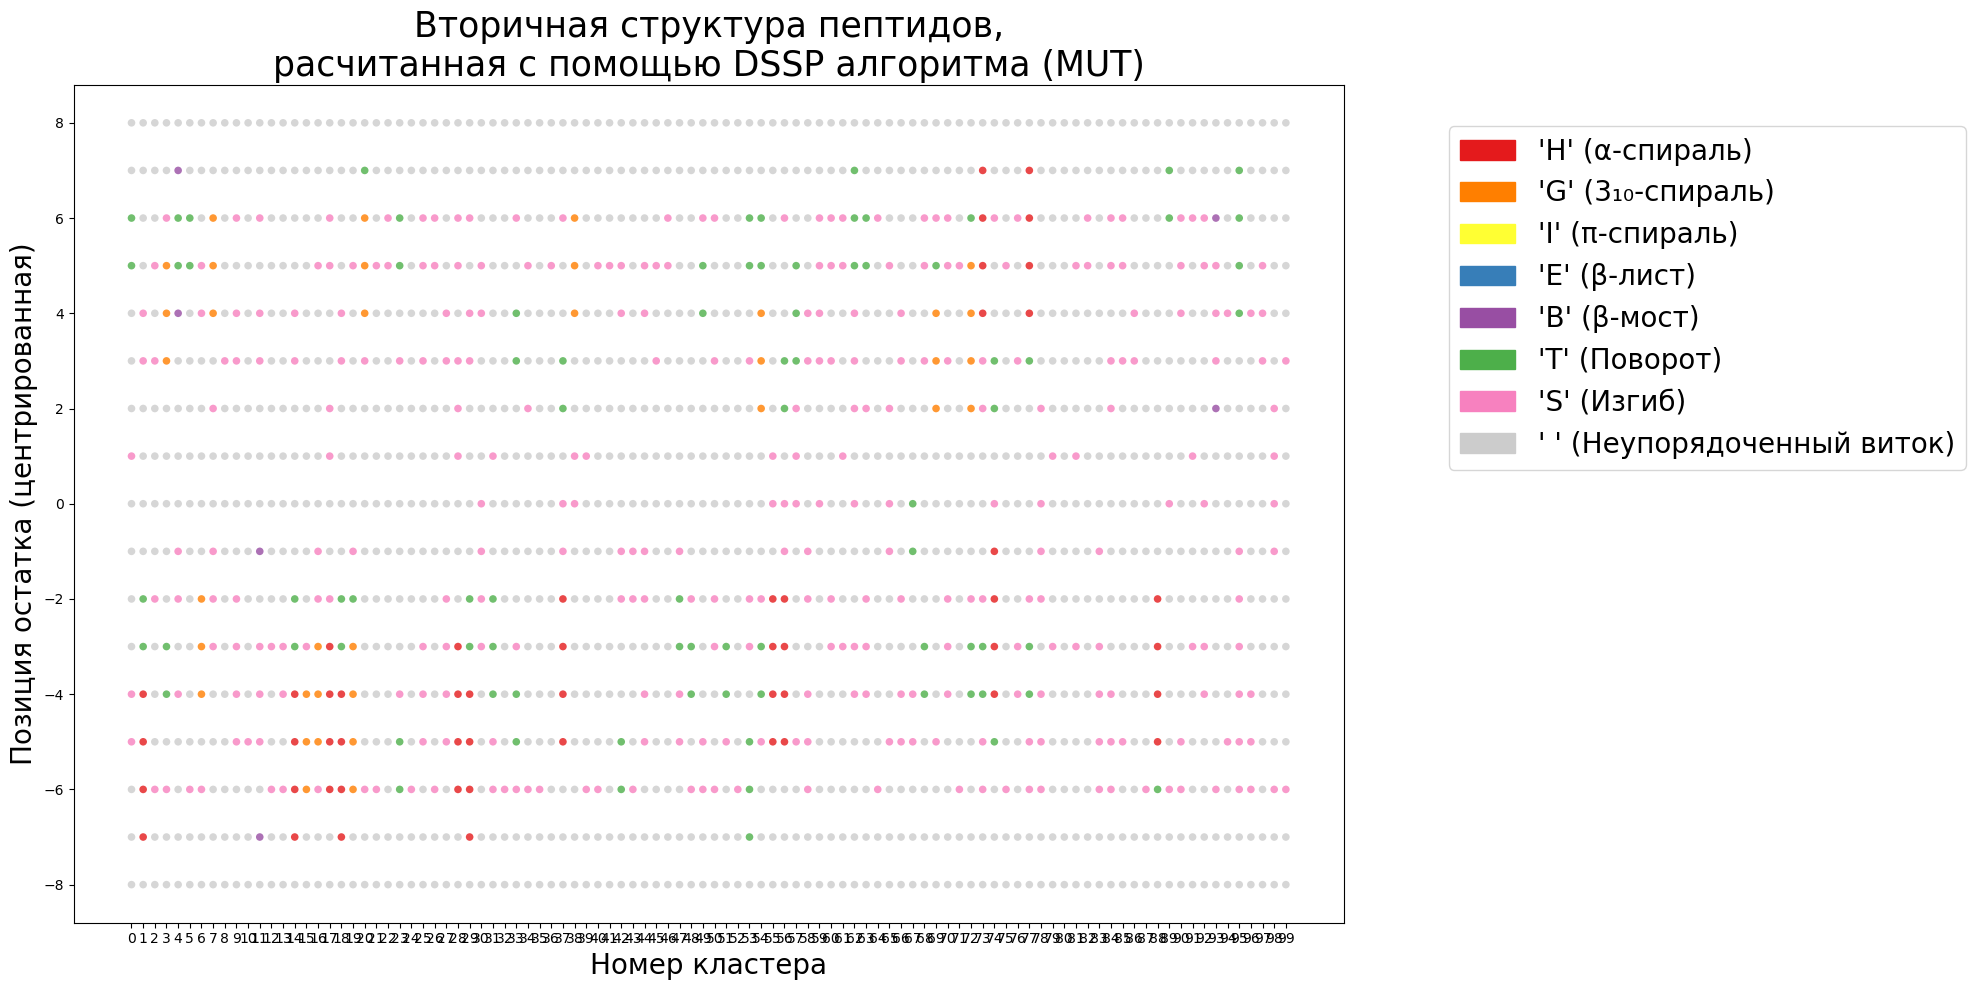

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_dssp_clusters(cluster_dssp, figsize=(20, 10), title="DSSP across clusters"):
    """
    cluster_dssp : list of lists (or strings) of DSSP characters
                   e.g., [ ['E','E',' ','H',...], [' ',' ','E',...], ... ]
    """
    n_clusters = len(cluster_dssp)
    L = len(cluster_dssp[0])
    # Center residues around 0: position i -> i - (L-1)/2
    y_positions = np.arange(L) - (L - 1) / 2

    # Color map for common DSSP codes
    cmap = {
        'H': '#e41a1c',   # alpha-helix (red)
        'G': '#ff7f00',   # 3-10 helix (orange)
        'I': '#ffff33',   # pi-helix (yellow)
        'E': '#377eb8',   # extended strand (blue)
        'B': '#984ea3',   # beta-bridge (purple)
        'T': '#4daf4a',   # turn (green)
        'S': '#f781bf',   # bend (pink)
        ' ': '#cccccc',   # coil / unstructured (light grey)
        '-': '#cccccc',   # alternative coil symbol
        '?': '#000000'    # unknown (black)
    }
    
    fig, ax = plt.subplots(figsize=figsize)
    
    for i, dssp_seq in enumerate(cluster_dssp):
        if isinstance(dssp_seq, str):
            dssp_seq = list(dssp_seq)
        for j, code in enumerate(dssp_seq):
            color = cmap.get(code, '#000000')
            ax.scatter(i, y_positions[j], color=color, s=30, edgecolors='none', alpha=0.8)
    
    ax.set_xlabel("Номер кластера", fontsize=20)
    ax.set_ylabel("Позиция остатка (центрированная)", fontsize=20)
    ax.set_title(title, fontsize=25)
    ax.set_xticks(range(n_clusters))
    # ax.axhline(17, color='black', linewidth=1.5, linestyle='--')
    # ax.axhline(-17, color='black', linewidth=1.5, linestyle='--')
    # ax.axhline(34, color='black', linewidth=1.5, linestyle='--')
    # ax.axhline(-34, color='black', linewidth=1.5, linestyle='--')
    # ax.axhline(0, color='black', linewidth=1.5, linestyle='--')
    legend_patches = [mpatches.Patch(color=color, label=f"'{code}' ({name})")
                      for code, color, name in [
                          ('H', '#e41a1c', 'α-спираль'),
                          ('G', '#ff7f00', '3₁₀-спираль'),
                          ('I', '#ffff33', 'π-спираль'),
                          ('E', '#377eb8', 'β-лист'),
                          ('B', '#984ea3', 'β-мост'),
                          ('T', '#4daf4a', 'Поворот'),
                          ('S', '#f781bf', 'Изгиб'),
                          (' ', '#cccccc', 'Неупорядоченный виток'),]]
    ax.legend(handles=legend_patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=1.5, fontsize=20)
    plt.tight_layout()
    # plt.savefig('1MUT.jpg', dpi=900)
    plt.show()
plot_dssp_clusters(candidates, title="Вторичная структура пептидов,\nрасчитанная с помощью DSSP алгоритма (MUT)")

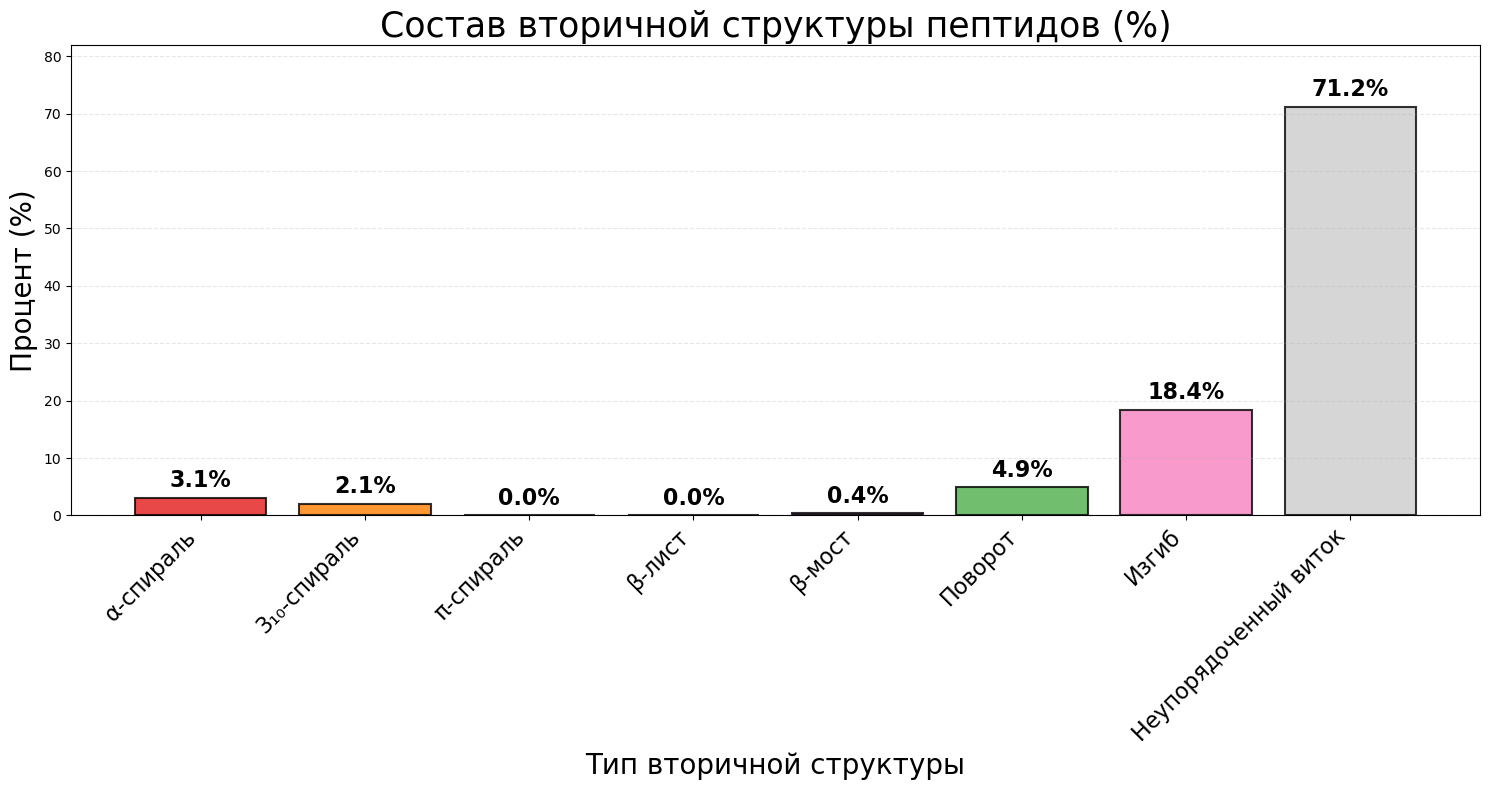

In [14]:
def plot_dssp_percentages(cluster_dssp, figsize=(15, 8), title="Secondary Structure Composition"):
    """
    Plots normalized percentages of different secondary structures.
    
    cluster_dssp : list of lists (or strings) of DSSP characters
    """
    from collections import Counter
    
    # Flatten all DSSP sequences
    all_dssp = []
    for dssp_seq in cluster_dssp:
        if isinstance(dssp_seq, str):
            all_dssp.extend(list(dssp_seq))
        else:
            all_dssp.extend(dssp_seq)
    
    # Count occurrences
    counts = Counter(all_dssp)
    
    # Color map (same as plot_dssp_clusters)
    cmap = {
        'H': '#e41a1c',   # alpha-helix (red)
        'G': '#ff7f00',   # 3-10 helix (orange)
        'I': '#ffff33',   # pi-helix (yellow)
        'E': '#377eb8',   # extended strand (blue)
        'B': '#984ea3',   # beta-bridge (purple)
        'T': '#4daf4a',   # turn (green)
        'S': '#f781bf',   # bend (pink)
        ' ': '#cccccc',   # coil / unstructured (light grey)
        '-': '#cccccc',   # alternative coil symbol
        '?': '#000000'    # unknown (black)
    }
    
    # Order codes and labels
    codes = ['H', 'G', 'I', 'E', 'B', 'T', 'S', ' ']
    labels = ['α-спираль', '3₁₀-спираль', 'π-спираль', 'β-лист', 'β-мост', 'Поворот', 'Изгиб', 'Неупорядоченный виток']
    
    # Calculate percentages
    total = len(all_dssp)
    percentages = [counts.get(code, 0) / total * 100 for code in codes]
    colors = [cmap[code] for code in codes]
    
    fig, ax = plt.subplots(figsize=figsize)
    bars = ax.bar(range(len(codes)), percentages, color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)
    
    # Add percentage labels on top of bars
    for bar, pct in zip(bars, percentages):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height + 1, 
                f'{pct:.1f}%', ha='center', va='bottom', fontsize=16, fontweight='bold')
    
    ax.set_xlabel("Тип вторичной структуры", fontsize=20)
    ax.set_ylabel("Процент (%)", fontsize=20)
    ax.set_title(title, fontsize=25)
    ax.set_xticks(range(len(codes)))
    ax.set_xticklabels(labels, fontsize=16, rotation=45, ha='right')
    ax.set_ylim(0, max(percentages) * 1.15)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.savefig('DSSP_precent_1MUT.jpg', dpi=900)
    plt.show()

# Plot secondary structure percentages
plot_dssp_percentages(candidates, title="Состав вторичной структуры пептидов (%)")